In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

/Users/stella/Downloads/IS/MVP2/Data Training/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
data_dir = '/Users/stella/Downloads/IS/MVP2/Data Training/content'

all_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.csv')]

df_list = []
for f in all_files:
    temp_df = pd.read_csv(f)
    match = re.search(r'sensors_data_(\d+)\.csv', f)
    user_id = int(match.group(1)) if match else 0 # Assign user 0 for 'pause_sign.csv'
    temp_df['user'] = user_id
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("--- Data Loaded and Combined Successfully ---")
print(f"Total rows: {len(df)}, Total columns: {len(df.columns)}")

--- Data Loaded and Combined Successfully ---
Total rows: 1992, Total columns: 442


In [3]:
label_col = 'SIGN'
user_col = 'user'

sensor_cols = df.select_dtypes(include=np.number).drop(columns=[user_col]).columns.tolist()

label_encoder = LabelEncoder()
df['sign_encoded'] = label_encoder.fit_transform(df[label_col])
num_classes = len(label_encoder.classes_)

scaler = StandardScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

print("--- Data Preprocessing Successful ---")
print(f"Found {len(sensor_cols)} sensor features and {num_classes} unique signs.")

--- Data Preprocessing Successful ---
Found 440 sensor features and 7 unique signs.


In [4]:
# --- CREATE SEQUENCES FOR CROSS-VALIDATION ---
def create_sequences(data, time_steps=50, step=25):
    sequences, labels, groups = [], [], []
    
    for _, group in data.groupby(['user', 'sign_encoded']):
        for i in range(0, len(group) - time_steps, step):
            sequences.append(group[sensor_cols].iloc[i:i + time_steps].values)
            labels.append(group['sign_encoded'].iloc[i])
            groups.append(group['user'].iloc[i]) 
    return np.array(sequences), np.array(labels), np.array(groups)

TIME_STEPS = 50
STEP = 25

X, y_int, groups = create_sequences(df, TIME_STEPS, STEP)

y = to_categorical(y_int, num_classes=num_classes)

print(f"Shape of all sequences (X): {X.shape}")
print(f"Shape of all labels (y): {y.shape}")
print(f"Found {len(np.unique(groups))} unique user groups in the sequence data.")

Shape of all sequences (X): (44, 50, 440)
Shape of all labels (y): (44, 7)
Found 3 unique user groups in the sequence data.


In [5]:
from sklearn.model_selection import GroupKFold
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- Group K-Fold Cross-Validation ---
n_groups = len(np.unique(groups))
N_SPLITS = n_groups
gkf = GroupKFold(n_splits=N_SPLITS)

print(f"--- Starting {N_SPLITS}-Fold Cross-Validation ---")

all_acc_scores = []
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    print(f"\n--- FOLD {fold + 1}/{N_SPLITS} ---")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Build the Model
    inputs = Input(shape=(TIME_STEPS, X_train.shape[2]))
    x = LSTM(64, return_sequences=True)(inputs)
    x = Dropout(0.5)(x)
    x = LSTM(64)(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the Model
    print(f"Training on {len(np.unique(groups[train_idx]))} user groups, testing on {len(np.unique(groups[test_idx]))} user group(s)...")
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=128,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Evaluate and store results
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Fold {fold + 1} Test Accuracy: {accuracy*100:.2f}%")
    all_acc_scores.append(accuracy)

print("\n\n--- Cross-Validation Summary ---")
print(f"Mean Accuracy: {np.mean(all_acc_scores)*100:.2f}%")
print(f"Standard Deviation of Accuracy: {np.std(all_acc_scores)*100:.2f}%")

--- Starting 3-Fold Cross-Validation ---

--- FOLD 1/3 ---


2025-11-07 01:25:28.467084: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-11-07 01:25:28.467118: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-07 01:25:28.467127: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-07 01:25:28.467439: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-07 01:25:28.467805: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Training on 2 user groups, testing on 1 user group(s)...


2025-11-07 01:25:30.036791: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Fold 1 Test Accuracy: 30.00%

--- FOLD 2/3 ---
Training on 2 user groups, testing on 1 user group(s)...
Fold 2 Test Accuracy: 100.00%

--- FOLD 3/3 ---
Training on 2 user groups, testing on 1 user group(s)...
Fold 3 Test Accuracy: 100.00%


--- Cross-Validation Summary ---
Mean Accuracy: 76.67%
Standard Deviation of Accuracy: 33.00%




--- Training Final Model on All Data for Detailed Analysis ---

--- Starting Final Training ---
Epoch 1/50
1/1 [==============================] - 2s 2s/step - loss: 2.0410 - accuracy: 0.1429 - val_loss: 1.9066 - val_accuracy: 0.3333
Epoch 2/50
1/1 [==============================] - 0s 51ms/step - loss: 1.7461 - accuracy: 0.4000 - val_loss: 1.8334 - val_accuracy: 0.4444
Epoch 3/50
1/1 [==============================] - 0s 42ms/step - loss: 1.5345 - accuracy: 0.6000 - val_loss: 1.7636 - val_accuracy: 0.6667
Epoch 4/50
1/1 [==============================] - 0s 41ms/step - loss: 1.3411 - accuracy: 0.8286 - val_loss: 1.6939 - val_accuracy: 0.7778
Epoch 5/50
1/1 [==============================] - 0s 42ms/step - loss: 1.3000 - accuracy: 0.7429 - val_loss: 1.6237 - val_accuracy: 0.6667
Epoch 6/50
1/1 [==============================] - 0s 40ms/step - loss: 1.0984 - accuracy: 0.8857 - val_loss: 1.5560 - val_accuracy: 0.6667
Epoch 7/50
1/1 [==============================] - 0s 43ms/step - loss:

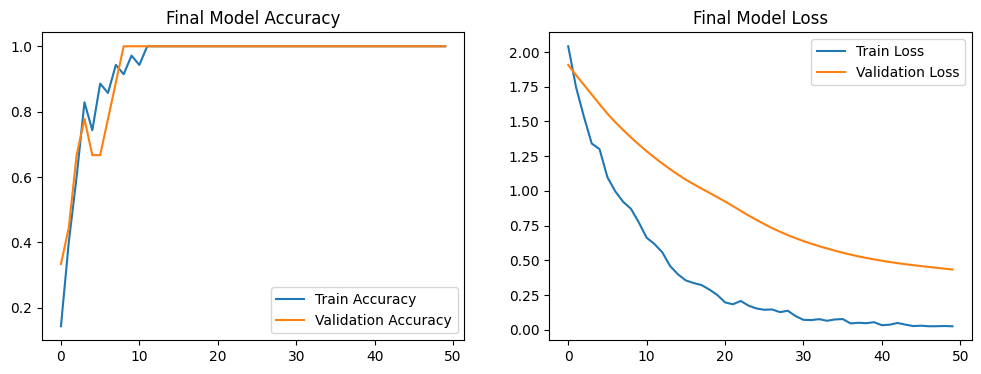



--- Final Model Performance Analysis (on all data) ---
2/2 [==============================] - 0s 19ms/step

Classification Report:
              precision    recall  f1-score   support

       PAUSE       1.00      1.00      1.00        10
       PROUD       1.00      1.00      1.00         6
     STUDENT       1.00      1.00      1.00         6
   THANK YOU       1.00      1.00      1.00         6
        THIS       1.00      1.00      1.00         6
          WE       1.00      1.00      1.00         6
        WORK       1.00      1.00      1.00         4

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44


Confusion Matrix:


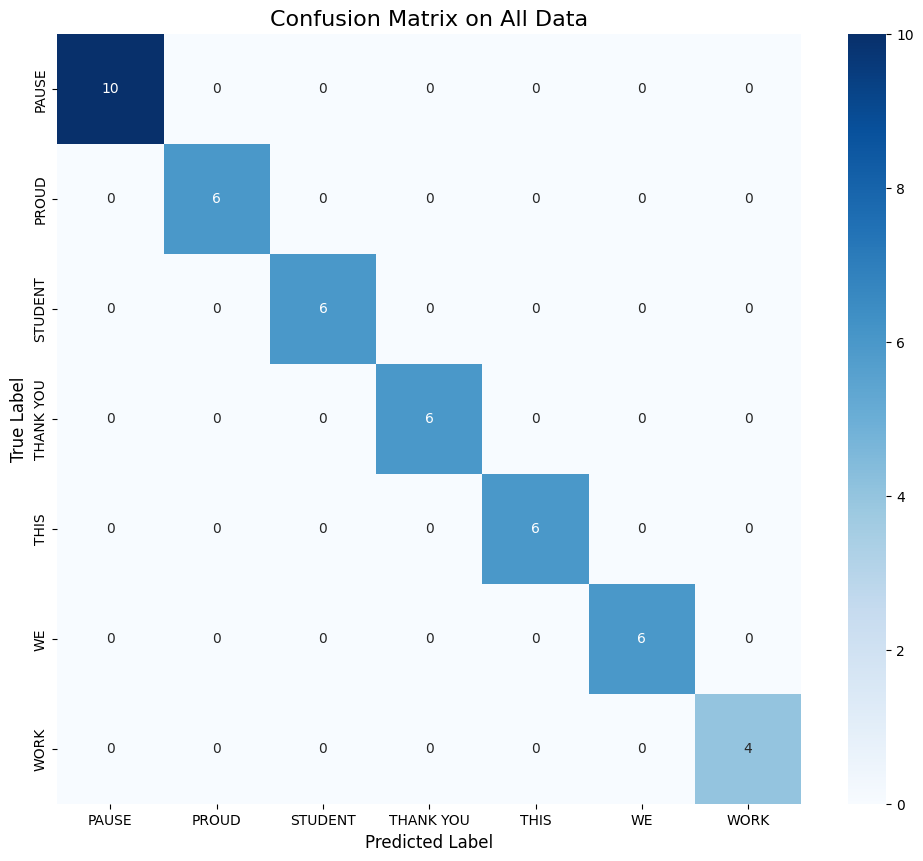

In [6]:
from sklearn.utils.multiclass import unique_labels

print("\n\n--- Training Final Model on All Data for Detailed Analysis ---")

inputs = Input(shape=(TIME_STEPS, X.shape[2]))
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.5)(x)
x = LSTM(64)(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)
final_model = Model(inputs=inputs, outputs=outputs)
final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- Starting Final Training ---")
history = final_model.fit(
    X, y,
    epochs=50,
    batch_size=128,
    validation_split=0.2, # Use 20% of all data for validation monitoring
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)],
    verbose=1
)

# 3. Plot Training History
print("\n\n--- Final Model Training History ---")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Final Model Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Final Model Loss')
plt.legend()
plt.show()

print("\n\n--- Final Model Performance Analysis (on all data) ---")
y_pred_probs = final_model.predict(X)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y, axis=1)

unique_labels_all = np.unique(np.concatenate((y_true, y_pred)))
filtered_class_names = [label_encoder.classes_[i] for i in unique_labels_all]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=unique_labels_all, target_names=filtered_class_names, zero_division=0))

print("\nConfusion Matrix:")
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred, labels=unique_labels_all)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=filtered_class_names, yticklabels=filtered_class_names, cmap='Blues')
plt.title('Confusion Matrix on All Data', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [7]:
model.save("Test1.h5")


/Users/stella/Downloads/IS/MVP2/Data Training/.venv/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
